# Quality control of Visium

To perform quality control of visium we have the `dotools_py.pp.importer_py()` function. This function compiles different methods to process samples. We need to define a list of H5 files that have been generated from a mapping tool like [SpaceRanger](https://www.10xgenomics.com/support/software/space-ranger/latest). Additionally, we need to provide the batch names for the samples, and additional metadata can be provided in the form of a dictionary.

The quality control involves filtering genes and cells:
- **Genes**: are removed based on their expression levels. Genes expressed in low amount of cells are excluded. By default, we consider that a gene is excluded if it is expressed in less than 5 cells
- **Spots**: are removed based on different parameters, including: number of genes, and number of UMI counts. *For Visium, a permissive quality control is recommended, since the more strick  we are the more information we lose*
    - Number of genes: cells are removed by absolute number of genes. A lower and upper threshold can be set.
    - Number of UMI counts: cells can be removed using two approaches: absolute or quantiles. A lower and upper threshold can be set and a combination of both approaches can be used (e.g., an absolute lower threshold and filter cells on the upper quantile).

Contrary to sc/snRNA-seq we do not filter spots based on mitochondrial content, since these do not represent low quality cells in this platform. We might want to remove the genes for downstream analysis depending on the set-up. Additionally, doublets cannot be identified since each spot represent a region with more than 1 cell. Lastly, it is recommended to identify regions with high hemoglobin content, since it might represent contamination.

After the quality control, the individual samples will be combined into one AnnData object and log-normalization, scaling and highly variable genes  will be calculated. To evaluate the quality control the distribution of total UMI, number of genes, mitochondrial genes and hemoglobin genes per cell will be plotted in a violin plot after the quality control. These plots will be saved in the folders containing the H5 files. Additionally, we also keep track on the number of spots and genes that have been removed in each quality control step.

First, we start setting up the environment and loading the required libraries

## Environment setup

In [1]:
import dotools_py as do
import pandas as pd
from IPython.display import display, SVG
import session_info

2026-03-06 09:53:33,821 - Jupyter enviroment detected. Using "inline" backend


To show how the quality control works, we are going to use one public dataset from 10X from the human heart.


In [2]:
do.dt.example_visium("/Users/david/Downloads/PublicVisium10x")

2026-03-03 13:41:48,639 - Downloading data to /Users/david/Downloads/PublicVisium10x


In [2]:
paths = [
    "/Users/david/Downloads/PublicVisium10x/",
]

adata = do.pp.importer_py(
    paths=paths,
    ids=["batch1"],
    metadata={"condition": ["healthy"], "tissue": ["heart"]},  # Additional metadata information
    batch_key="batch",  # Column in obs to save batch information
    remove_doublets=False,
    min_genes_in_cell=200,
    min_cells_with_genes=5,
    cut_mt=None,
    n_reads=10_000,
    min_counts=500,  # Filter cells with less than 500 genes
    max_counts=100_000,
    normalisation_method="LogNormalisation",
    metrics_patterns=["mt-", ("rps", "rpl"), "^hb.*-"],
    metrics_names=["mt", "ribo", "hb"],
    random_state=0,
    technology="visium"
)

2026-03-06 09:53:33,839 - For Visium, removing doublets is not recommended, ignoring this step
2026-03-06 09:53:33,839 - For Visium, identifying hemoglobin genes is recommended, adding the pattern
2026-03-06 09:53:33,840 - QualityControl Plots will be saved in
/Users/david/Downloads/PublicVisium10x
reading /Users/david/Downloads/PublicVisium10x/filtered_feature_bc_matrix.h5
 (0:00:00)
2026-03-06 09:53:34,437 - Remove cells with low number of genes
filtered out 11 cells that have less than 200 genes expressed
2026-03-06 09:53:34,492 - Remove genes lowly expressed
filtered out 19885 genes that are detected in less than 5 cells
2026-03-06 09:53:34,561 - Remove cells based on nUMI counts
filtered out 1 cells that have less than 500 counts
2026-03-06 09:53:35,130 - Concatenating samples
2026-03-06 09:53:35,150 - Normalisation of the expression
normalizing counts per cell
    finished (0:00:00)
2026-03-06 09:53:35,192 - Finding Highly Variable Genes shared across samples
extracting highly va

In [3]:
adata

AnnData object with n_obs × n_vars = 4235 × 16716
    obs: 'in_tissue', 'array_row', 'array_col', 'batch', 'condition', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial', 'X_pca'
    layers: 'counts', 'logcounts'

## Evaluation of the preprocessing

We can now check the quality control plots that were generated:

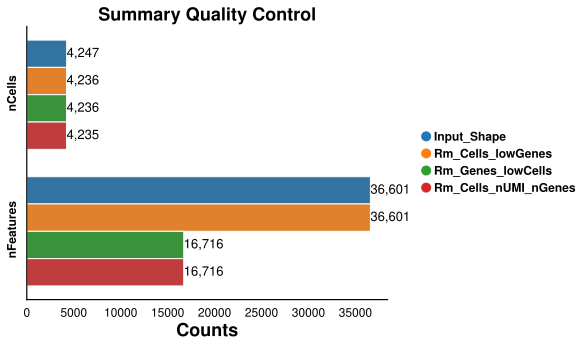

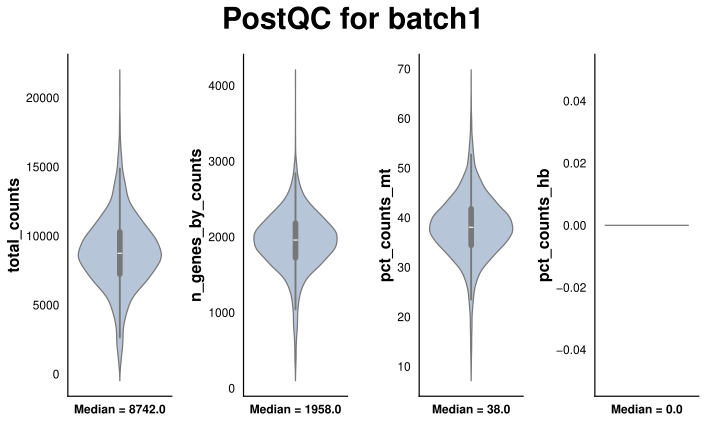

In [4]:
files = [
    "/Users/david/Downloads/PublicVisium10x/260303_QC_Metricsbatch1.svg",
    "/Users/david/Downloads/PublicVisium10x/Vln_PostQC_batch1.svg",
]
display(
    SVG(files[0]),
    SVG(files[1]),
)

We can observe that we have not remove almost  any of spots.  Besides these plots, we also have an ExcelSheet that kept track on the thresholds used during the quality control.

In [5]:
table = pd.read_excel("/Users/david/Downloads/PublicVisium10x/260303_Metrics_batch1.xlsx")
table

,QC_Step,nCells,nFeatures,Comments
0,Input_Shape,4247,36601,NaN
1,Rm_Cells_lowGenes,4236,36601,Remove cells with <200 genes
2,Rm_Genes_lowCells,4236,16716,Remove genes express in less than 5 cells
3,Rm_Cells_nUMI_nGenes,4235,16716,Remove cells based on nUMI counts[Absolute (Mi...


Since this a spatial transcriptomics dataset, we can also visualize the distribution of these quality control metrics.

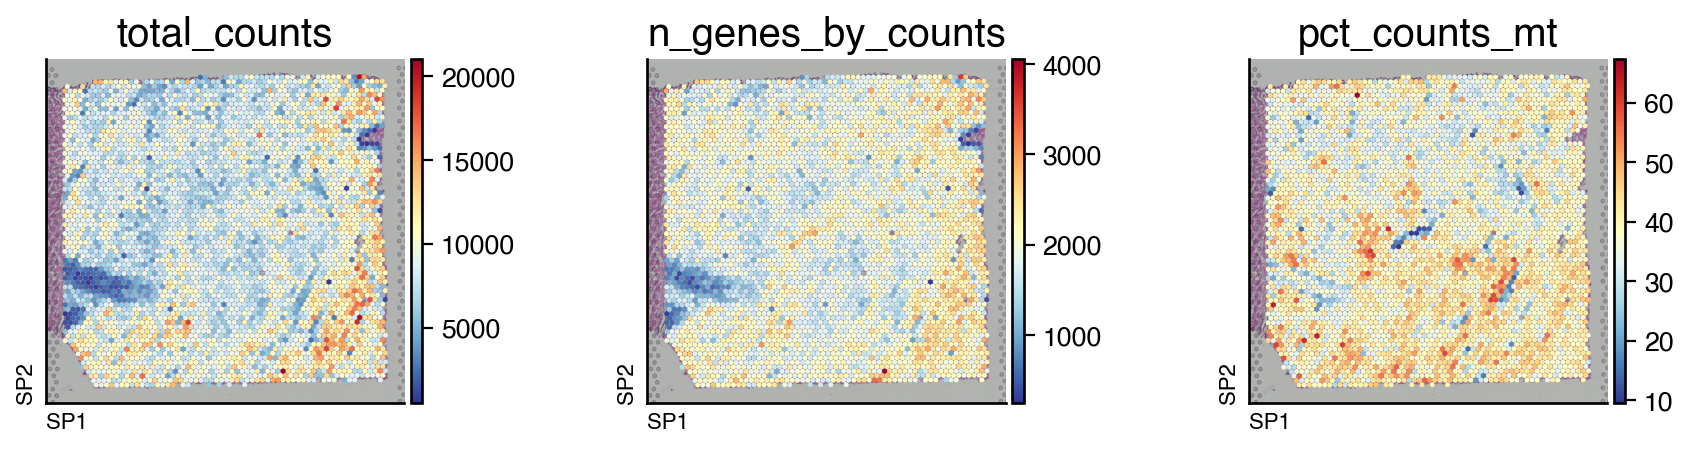

In [6]:
do.pl.slides(adata, ["total_counts", "n_genes_by_counts", "pct_counts_mt"], figsize=(12, 3), cmap="RdYlBu_r")

## Integration and clustering
After the quality control, we can now proceed to the batch correction and integration of the samples. In this example, we only have 1 slide, so we do not need to perform batch correction and can run PCA directly.
Following dimensionality reduction, we can identify niches.

In [7]:
do.tl.integrate_data(
    adata,
    batch_key="batch",
    integration_method="pca",
    resolution=0.75,  # Resolution for leiden algorithm
    technology="spatial",
)

2026-03-06 09:53:50,022 - Computing HVGs
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
2026-03-06 09:53:50,883 - Finding neighbors
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
Creating graph using `grid` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
2026-03-06 09:54:00,461 - Run UMAP
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)
2026-03-06 09:54:04,249 - Clus

## Niche exploration
We can now visualize the clusters:

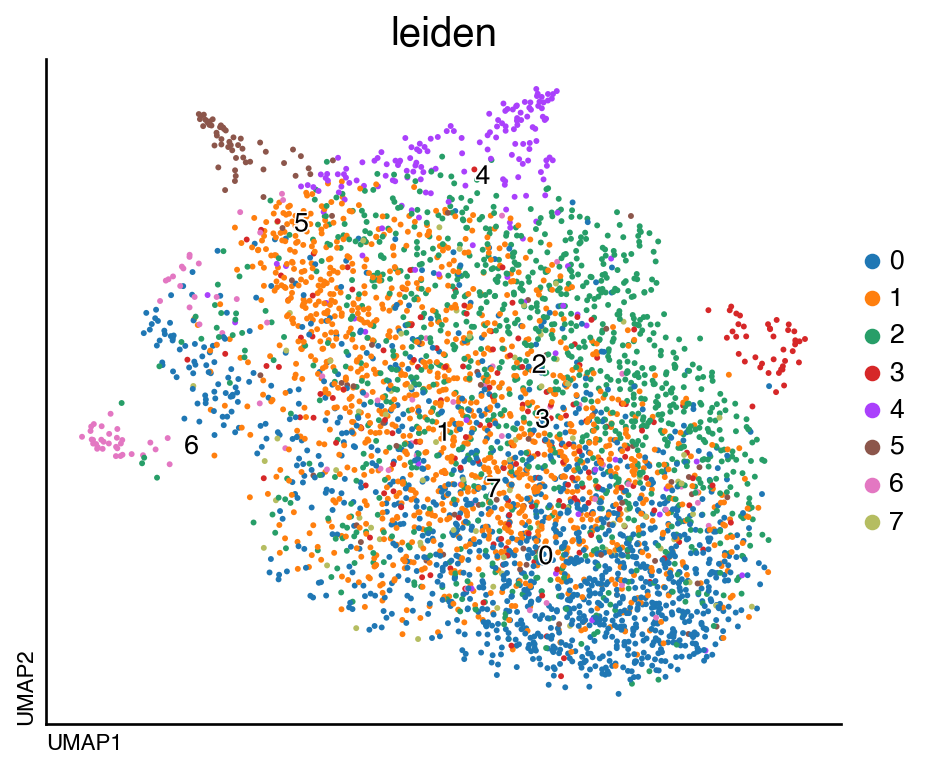

<Figure size 320x400 with 0 Axes>

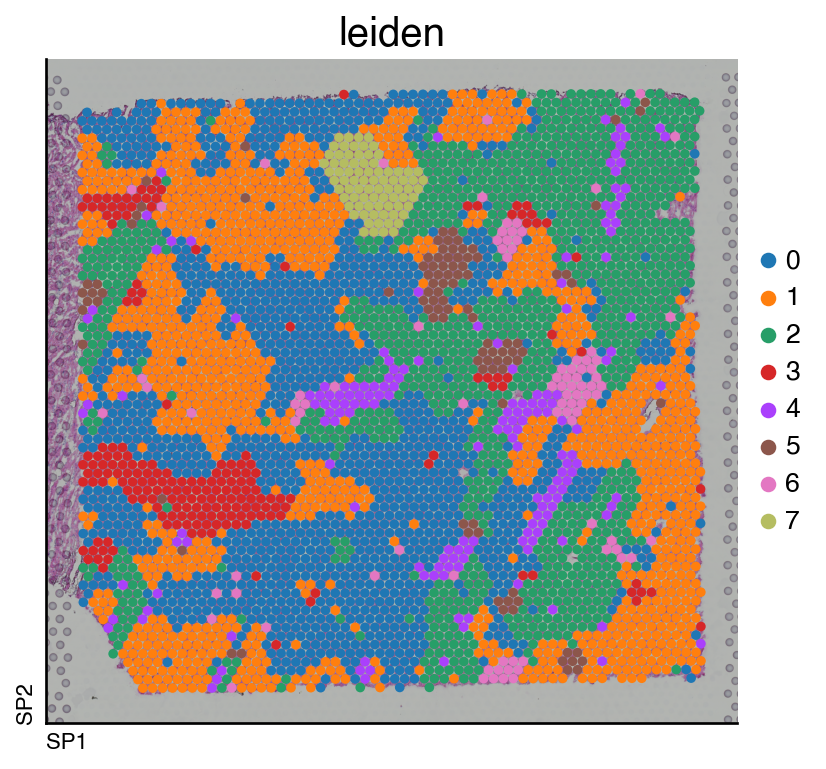

In [8]:
do.pl.umap(adata, "leiden", labels="leiden", figsize=(6, 5))
do.pl.slides(adata, "leiden", figsize=(6, 5))

In [17]:
adata.write("/Users/david/Downloads/PublicVisium10x/adata_visium.h5ad")

In [20]:
session_info.show(na=False, cpu=True, excludes=["backports"], std_lib=True, dependencies=True, html=True)